# Bias in Bios: erasing gender with `jevu`

Runs the package on a **real** fairness dataset
([Bias in Bios](https://huggingface.co/datasets/LabHC/bias_in_bios): biographies labeled with
`occupation` and `gender`). Everything goes through **`ConceptScrubber`** — it labels the concept
with JEV and erases it. We:

1. bring our own **texts** and **embeddings** (`text-embedding-3-small`),
2. score the concept *"is this about a woman?"* with `ConceptScrubber.concept_scores` (JEV, zero-shot),
3. erase it with `ConceptScrubber` (LEACE and INLP),
4. audit against the **true** labels — gender recoverability, occupation accuracy, TPR gap,
5. **plot the embedding space before vs. after erasure**.

All API responses are cached in `examples/.jev_debias_cache`, so this notebook runs offline from
any working directory (JupyterLab, VS Code, or nbconvert). Needs `pip install "jevu[examples]"`.

In [1]:
import os, sys, json, hashlib
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

# Locate the repo (and its cache) regardless of the kernel's working directory,
# so this runs the same from JupyterLab, VS Code, or nbconvert.
def _repo_root(start):
    for q in [Path(start).resolve(), *Path(start).resolve().parents]:
        if (q / 'pyproject.toml').exists() and (q / 'src' / 'jevu').exists():
            return q
    return Path(start).resolve()
ROOT = _repo_root(os.getcwd())
if str(ROOT / 'src') not in sys.path: sys.path.insert(0, str(ROOT / 'src'))
from jevu import ConceptScrubber, concept_auc, tpr_gap

# load API keys from the repo .env (only needed on a cache miss)
_envf = ROOT / '.env'
if _envf.exists():
    for _line in _envf.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith('#') and '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k.strip(), _v.strip().strip('\'"'))

CACHE = ROOT / 'examples' / '.jev_debias_cache'; CACHE.mkdir(parents=True, exist_ok=True)
SEED = 2026
DATASET, CONFIG, SPLIT = 'LabHC/bias_in_bios', 'default', 'test'
N = 900
DENSE_MODEL = 'text-embedding-3-small'
HF_ROWS = 'https://datasets-server.huggingface.co/rows'
GENDER_Q = 'Does the text describe a woman or a female person?'
def digest(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
def save_json(p, x): p.write_text(json.dumps(x, ensure_ascii=False))
print('jevu example | cache:', CACHE, '| exists:', CACHE.exists())

jevu example | cache: /Users/chingis/Desktop/jevu/examples/.jev_debias_cache | exists: True


## 1. Bring your data: texts + embeddings

Data prep is your responsibility (the package takes embeddings as input). `httpx`/`openai` are
imported lazily, so a cache-only run needs neither.

In [2]:
def hf_page(offset, length=100):
    path = CACHE/f'bios_{SPLIT}_{offset}_{length}.json'
    if path.exists(): return json.loads(path.read_text())
    import httpx
    params = {'dataset': DATASET, 'config': CONFIG, 'split': SPLIT, 'offset': int(offset), 'length': int(length)}
    r = httpx.get(HF_ROWS, params=params, timeout=60); r.raise_for_status()
    data = r.json(); save_json(path, data); return data

def load_bios(n, seed):
    path = CACHE/f'bios_sample_{n}_{seed}.json'
    if path.exists(): return json.loads(path.read_text())['rows']
    total = hf_page(0, 1)['num_rows_total']
    rng = np.random.default_rng(seed); offsets = list(rng.permutation(np.arange(0, total, 100)))
    rows = []
    for off in offsets:
        for item in hf_page(int(off), 100)['rows']:
            r = item['row']; t = str(r['hard_text'] or '').strip()
            if t: rows.append({'text': t[:700], 'prof': int(r['profession']), 'gender': int(r['gender'])})
        if len(rows) >= n: break
    rng.shuffle(rows); rows = rows[:n]; save_json(path, {'rows': rows}); return rows

def embed_dense(texts):
    path = CACHE/f'dense_{digest({"m": DENSE_MODEL, "t": texts})}.json'
    if path.exists(): return np.asarray(json.loads(path.read_text()), dtype=float)
    from openai import OpenAI
    client = OpenAI(timeout=90); vecs = []
    for s in range(0, len(texts), 200):
        vecs.extend(x.embedding for x in client.embeddings.create(model=DENSE_MODEL, input=texts[s:s+200]).data)
    v = np.asarray(vecs, dtype=float); save_json(path, v.tolist()); return v

rows = load_bios(N, SEED)
texts = [r['text'] for r in rows]
prof = np.array([r['prof'] for r in rows])            # occupation label -> KEEP
gender_raw = np.array([r['gender'] for r in rows])    # gender label     -> ERASE
X = normalize(embed_dense(texts))                     # off-the-shelf embeddings (frozen)
print(len(texts), 'bios |', len(np.unique(prof)), 'professions | embeddings', X.shape)

900 bios | 28 professions | embeddings (900, 1536)


## 2. Score the concept with `ConceptScrubber.concept_scores`

One plain-English question → a calibrated 0–1 score per text (JEV, zero-shot). We detect the "female"
polarity from the scores (not hardcoded) and check agreement with the dataset's true labels.

In [3]:
scorer = ConceptScrubber(concept=GENDER_Q, cache_dir=str(CACHE))
g = scorer.concept_scores(texts)                       # cached -> no API calls
means = {int(v): float(g[gender_raw == v].mean()) for v in np.unique(gender_raw)}
female_val = max(means, key=means.get)
female_true = (gender_raw == female_val).astype(int)   # ground truth (for AUDIT)
jev_female = (g >= 0.5).astype(int)                    # JEV labels  (for ERASURE)
print('mean JEV female-score by gender value:', {k: round(v, 2) for k, v in means.items()}, '-> female =', female_val)
print('JEV vs true gender agreement:', round(float((jev_female == female_true).mean()), 3))

mean JEV female-score by gender value: {0: 0.05, 1: 0.96} -> female = 1
JEV vs true gender agreement: 0.981


## 3. Erase with `ConceptScrubber`, then audit against true labels

We fit each scrubber on the **training** split with JEV's labels, apply it to all embeddings, and
measure on held-out data with the **true** labels.

In [4]:
idx = np.arange(len(texts))
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=female_true)

def occ_metrics(Xtr_, Xte_):
    clf = LogisticRegression(max_iter=3000).fit(Xtr_, prof[tr]); pred = clf.predict(Xte_)
    return accuracy_score(prof[te], pred), tpr_gap(prof[te], pred, female_true[te], 10)

results = []
acc, gap = occ_metrics(X[tr], X[te])
results.append(('raw (no erasure)', concept_auc(X, female_true), acc, gap))
scrubbed = {}
for name, method in [('LEACE', 'leace'), ('INLP', 'inlp')]:
    scr = ConceptScrubber(method=method)
    scr.fit(embeddings=X[tr], labels=jev_female[tr])   # erase using JEV labels (label-free)
    Xd = scr.transform(embeddings=X)                   # apply to all rows
    scrubbed[name] = Xd
    acc, gap = occ_metrics(Xd[tr], Xd[te])
    results.append((name, concept_auc(Xd, female_true), acc, gap))

print(f"{'method':<18}{'gender AUC':>12}{'occupation acc':>16}{'TPR gap':>10}")
for n, a, ac, gp in results:
    print(f"{n:<18}{a:>12.3f}{ac:>16.3f}{gp:>10.3f}")

method              gender AUC  occupation acc   TPR gap
raw (no erasure)         1.000           0.648     0.094
LEACE                    0.376           0.630     0.087
INLP                     0.353           0.622     0.077


## 4. Plot the space before vs. after erasure

**Top row** projects every embedding onto the *gender direction* (a probe's normal): women vs. men
separate cleanly **before**, and collapse onto each other **after**. **Bottom row** is a 2-D PCA
(same axes before/after) coloured by the top occupations — those clusters are largely preserved.

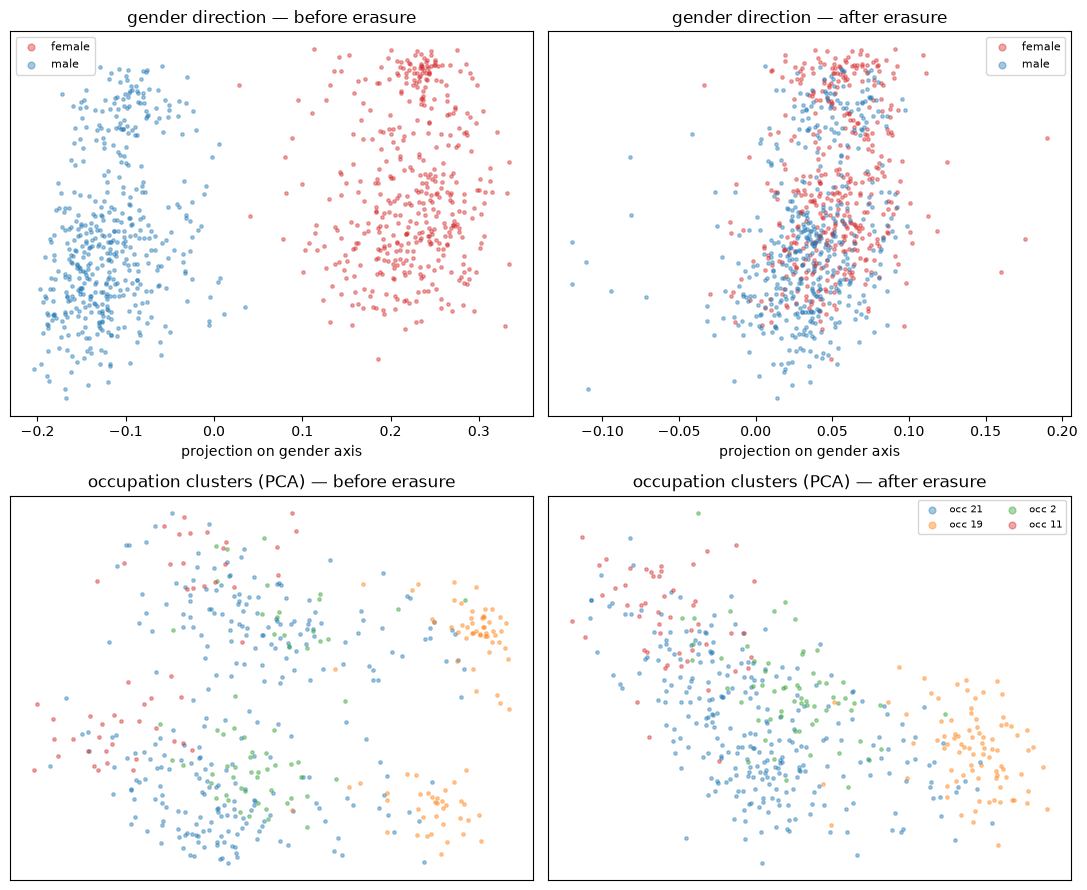

In [5]:
X_before, X_after = X, scrubbed['LEACE']

u = LogisticRegression(max_iter=2000).fit(X_before, female_true).coef_[0]; u = u / np.linalg.norm(u)
pc1 = PCA(n_components=1, random_state=SEED).fit_transform(X_before)[:, 0]
pca2 = PCA(n_components=2, random_state=SEED).fit(X_before)           # fit once -> comparable axes
PB, PA = pca2.transform(X_before), pca2.transform(X_after)
vals, counts = np.unique(prof, return_counts=True); top = vals[np.argsort(-counts)[:4]]

fig, ax = plt.subplots(2, 2, figsize=(11, 9))
for col, (M, ttl) in enumerate([(X_before, 'before'), (X_after, 'after')]):
    xg = M @ u
    for gv, lab, c in [(1, 'female', 'tab:red'), (0, 'male', 'tab:blue')]:
        m = female_true == gv
        ax[0, col].scatter(xg[m], pc1[m], s=6, alpha=0.4, c=c, label=lab)
    ax[0, col].set_title(f'gender direction — {ttl} erasure')
    ax[0, col].set_xlabel('projection on gender axis'); ax[0, col].set_yticks([])
    ax[0, col].legend(markerscale=2, fontsize=8)
for col, (P, ttl) in enumerate([(PB, 'before'), (PA, 'after')]):
    for t in top:
        m = prof == t
        ax[1, col].scatter(P[m, 0], P[m, 1], s=6, alpha=0.4, label=f'occ {t}')
    ax[1, col].set_title(f'occupation clusters (PCA) — {ttl} erasure')
    ax[1, col].set_xticks([]); ax[1, col].set_yticks([])
ax[1, 1].legend(fontsize=7, markerscale=2, ncol=2)
plt.tight_layout(); plt.show()

## 5. Reading it

- **Gender AUC** falls from ~1.0 toward ~0.5 and the gender axis collapses in the plot — gender is no
  longer linearly recoverable.
- **Occupation accuracy** is largely preserved and the PCA occupation clusters stay put.
- **TPR gap** shrinks — fairer occupation predictions across gender.

LEACE (closed-form, minimal-damage) typically preserves more utility than INLP at equal erasure.
The gains are modest and there is a real fairness–utility tradeoff — gender legitimately correlates
with some occupations. See the README for the math and caveats.